In [1]:
import time; start = time.time()

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import wavelab as wl
tqdm = wl.tqdm

In [2]:
wl.dark_mode = True
plt.rcParams.update({
    'figure.facecolor': "#000000",
    'axes.facecolor': "#000000",
    'axes.edgecolor': "#ECEAEA",
    'axes.labelcolor':"#FFFFFF",
    'xtick.color': "#ffffff",
    'ytick.color': "#ffffff",
    'grid.color': "#767676ff",
    'text.color': "#ffffff",
    'lines.color': '#f92672',
    'axes.prop_cycle': plt.cycler(color=['#f92672', '#66d9ef', '#a6e22e', '#fd971f', '#9effff', '#ae81ff'])
})

In the scalar experiments, we only saw intensity ($I = |E|^2$). Now we look at interaction of vector components.

---

## 1. 3D fields
The function below, `field_lines`, visualizes three aspects of the electromagnetic field:
1. E-Field: The instantaneous force on a charge.
2. B-Field: The instantaneous magnetic response.
3. Poynting Vector (S): The instantaneous flow of power through space.

All of them are visualised with streamlines for transverse components and longitudinal component for background.

In [3]:
def field_lines(config,z_val,prune=False):
    print('Setting up the experiment...')
    engine = wl.setup_engine(config)
    fields = engine.compute_on_op(z=z_val, need_derivs=False)
    E, B = fields.E, fields.B
    print ('Preparing plots...')
    S = 0.5 * np.real(np.cross(E, np.conj(B), axis=0))
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
    extent = engine.op_extent

    Ex_real, Ey_real, Ez_real = np.real(E)
    ax1.imshow(Ez_real, extent=extent, cmap='berlin', origin='lower')
    ax1.streamplot(engine.X, engine.Y, Ex_real, Ey_real,
                   color='white', linewidth=0.7, density=1.3)
    ax1.set_title('Instantaneous E-field')
    ax1.set_xlim(engine.x.min(), engine.x.max())
    ax1.set_ylim(engine.y.min(), engine.y.max())

    
    Bx_real, By_real, Bz_real = np.real(B)
    ax2.imshow(Bz_real, extent=extent, cmap='berlin', origin='lower')
    ax2.streamplot(engine.X, engine.Y, Bx_real, By_real,
                   color='white', linewidth=0.7, density=1.7)
    ax2.set_title('Instantaneous B-field')
    ax2.set_xlim(engine.x.min(), engine.x.max())
    ax2.set_ylim(engine.y.min(), engine.y.max())
    
    Sx, Sy, Sz = S
    im = ax3.imshow(Sz, extent=extent, cmap='magma', origin='lower')
    ax3.streamplot(engine.X, engine.Y, Sx, Sy,
                   color='white', linewidth=0.9, density=1.2)
    ax3.set_title('Instantaneous Poynting(S) field')
    ax2.set_title('Instantaneous B-field')
    ax3.set_xlim(engine.x.min(), engine.x.max())
    ax3.set_ylim(engine.y.min(), engine.y.max())
    
    fig.colorbar(im, ax=ax3, label='S along z')
    plt.tight_layout()
    
    plt.show()
    return E,B


Setting up the experiment...
Preparing plots...


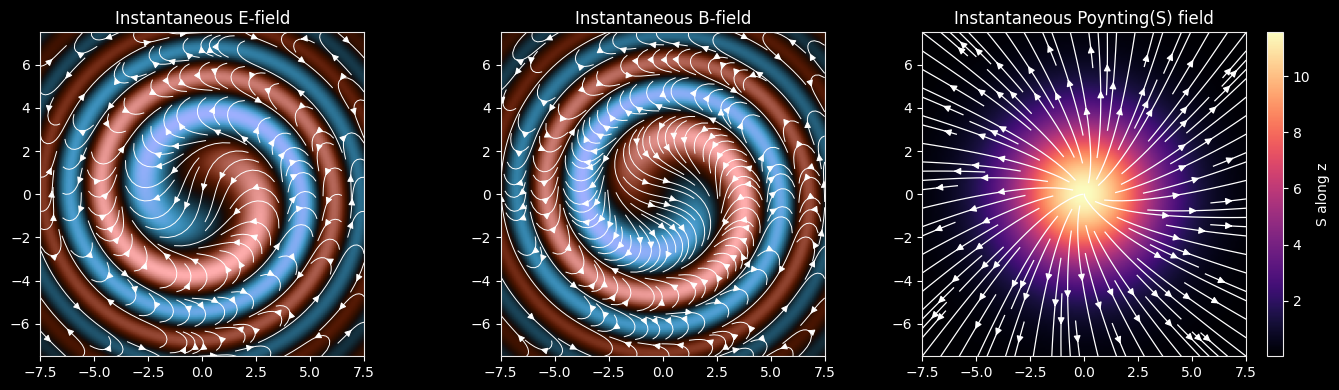

In [4]:
config = wl.get_config()

config.source.pol_vect = [1,1j]
config.source.num_modes = 30_000
config.source.randomize.off()

config.op.size = (15,15)
config.op.spacing = 0.1
E, B = field_lines(config,15, True)


Setting up the experiment...
Preparing plots...


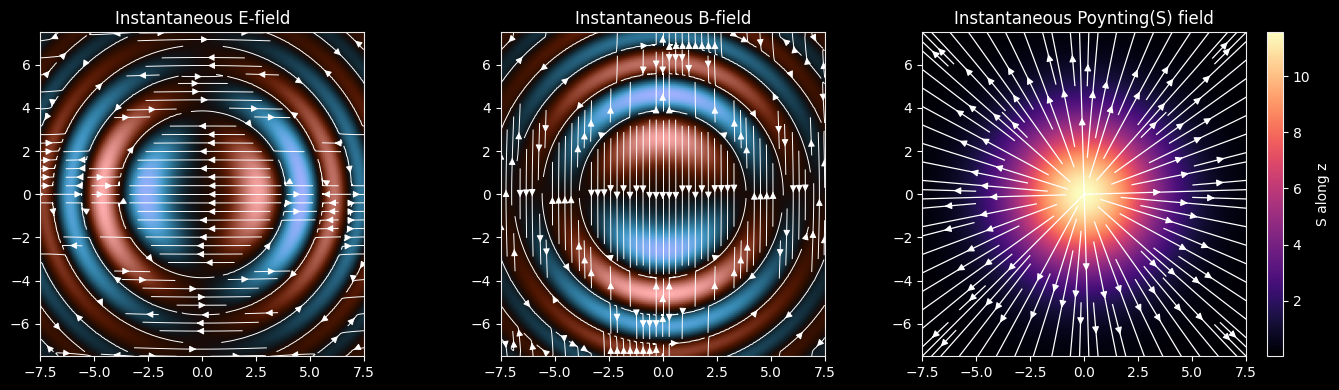

In [5]:
config.source.pol_vect = [1,0]
E1,B1 = field_lines(config,15,True)

Setting up the experiment...
Preparing plots...


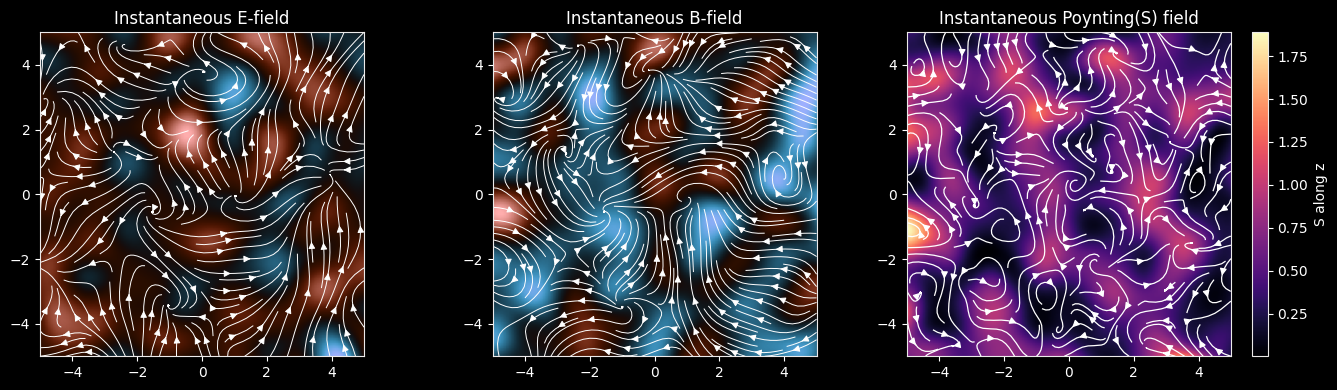

In [6]:
field_lines(wl.get_config(),15);

Unlike the clean geometric aspects of circular and linear polarisation, here all of E, B, S behaves like a turbulant fluid - forming vortices/sources etc.

---
## 2. Polarisation Singularities (stokes)

But speckle pattern above isn't just random noise; it has a rigid skeleton.

We visualize this by looking at Polarization Singularities (C-Points).
- These are specific points where the light is *purely circular*.
- The orientation of the polarization ellipse (azimuth) is *undefined* here.
- Surrounding vectors rotate around these points, forming topological defects (Star, Lemon, Monstar).

The plot below visualizes this "Fingerprint" of the field. \
The background is set to highlight regions of linear polarisation, L-lines. 
Streamlines show the orientation flow and their color is determined by handedness.

At few positions, the polarisation ellipse (colored by handedness) are drawn.

In [7]:
import matplotlib.pyplot as plt
import cmocean

def align_director_field_bfs(Ux, Uy):
    """
    Aligns a director field using Breadth-First Search (Flood Fill).
    This spreads the alignment radially from the center, ensuring that
    topological discontinuities (branch cuts) are minimized to short
    seams connecting singularities, rather than global stripes.
    """
    rows, cols = Ux.shape
    visited = np.zeros((rows, cols), dtype=bool)
    
    # Start from the center of the image (usually a safe bet for good alignment)
    start_r, start_c = rows // 2, cols // 2
    
    # Queue for BFS: stores (row, col)
    # We use a list and an index pointer for speed over true pop(0)
    queue = [(start_r, start_c)]
    visited[start_r, start_c] = True
    
    idx = 0
    while idx < len(queue):
        r, c = queue[idx]
        idx += 1
        
        # Current vector
        u_curr, v_curr = Ux[r, c], Uy[r, c]
        
        # Check 4 neighbors (Up, Down, Left, Right)
        neighbors = []
        if r > 0: neighbors.append((r - 1, c))
        if r < rows - 1: neighbors.append((r + 1, c))
        if c > 0: neighbors.append((r, c - 1))
        if c < cols - 1: neighbors.append((r, c + 1))
        
        for nr, nc in neighbors:
            if not visited[nr, nc]:
                # Dot product to check alignment
                dot = u_curr * Ux[nr, nc] + v_curr * Uy[nr, nc]
                
                # If pointing opposite, flip the neighbor
                if dot < 0:
                    Ux[nr, nc] *= -1
                    Uy[nr, nc] *= -1
                
                visited[nr, nc] = True
                queue.append((nr, nc))
                
    return Ux, Uy

def polarisation_landscape(config:wl.Config, z_val,ellipse=True):
    engine = wl.setup_engine(config)
    finder = wl.SingularityFinder(engine)
    print('Computing field data...')
    fields = engine.compute_on_op(z=z_val, need_b=False, need_derivs=False)
    E = fields.E
    I = fields.intensity_E
    I /= np.max(I)
    params = wl.get_stokes_params(E1=E[0], E2=E[1], normalize=True)
    s1, s2 = params['s1'], params['s2']
    
    print('Finding stokes C points...')
    points = finder.find_stokes_C_points(z_val, E)
    
    print('Plotting points...')
    scale = 10 * 1/max(config.op.size)
    figsize = (config.op.size[0] * scale, config.op.size[1] * scale)
    plt.figure(figsize=figsize)  
    extent = [engine.x.min(), engine.x.max(), engine.y.min(), engine.y.max()]

    data = wl.decompose_in_basis(E1=E[0], E2=E[1], u=[1, 1j]) 
    phi_L = np.angle(data['E_v']) 
    I_L = np.abs(data['E_v']); I_L /= np.max(I_L)
    plt.imshow(phi_L, extent=extent, cmap=cmocean.cm.phase, origin='lower',alpha=I)
    
    colors = {'Star': 'magenta', 'Lemon': 'yellow', 'Monstar': 'cyan'}
    for typ in colors:
        pts = [p for p in points if p['type'] == typ]
        X = [p['position'][0] for p in pts]
        Y = [p['position'][1] for p in pts]
        if pts:
            plt.scatter(X, Y, c=colors[typ], s=300, edgecolors='k', label=typ, zorder=10)

    print('Calculating streamlines...')
    # 1. Calculate raw director angle
    psi = 0.5 * np.arctan2(s2, s1)
    
    # 2. Convert to vectors
    U_raw = np.cos(psi)
    V_raw = np.sin(psi)
    
    # 3. FIX: Flood-fill alignment
    # This aligns vectors relative to the center, pushing cuts behind singularities
    U_clean, V_clean = align_director_field_bfs(U_raw, V_raw)

    # 4. Streamplot
    plt.streamplot(engine.X, engine.Y, U_clean, V_clean, 
                   color='black', linewidth=2, density=1.2, arrowsize=0,)

    plt.xlim(engine.x.min(), engine.x.max())
    plt.ylim(engine.y.min(), engine.y.max())


    from matplotlib.patches import Ellipse
    n = 10/max(*figsize)
    nx, ny = int(figsize[0]*n),int(figsize[1]*n)
    x_idx = np.linspace(0, engine.X.shape[1]-1, nx, dtype=int)
    y_idx = np.linspace(0, engine.Y.shape[0]-1, ny, dtype=int)
    params = wl.get_pol_ellipse_params(E1=E[0],E2=E[1])

    psi, a, b, hand = params['psi'], params['a'], params['b'], params['handedness']

    # Ellipse sampling
    scale = 0.4 * (engine.x.max() - engine.x.min()) / nx

    if ellipse:
        for i in y_idx:
            for j in x_idx:
                x0 = engine.X[i, j]
                y0 = engine.Y[i, j]

                psi_ij = psi[i, j]

                # Semi-axes
                A = scale * a[i,j]
                B = scale * b[i,j]
                s = np.sqrt(a[i,j]**2+b[i,j]**2)
                s=1
                A = A / s 
                B = B / s
                
                # Handedness
                color = 'white'

                e = Ellipse(
                    (x0, y0),
                    width=2 * A,
                    height=2 * B,
                    angle=np.degrees(psi_ij),
                    edgecolor=color,
                    facecolor='none',
                    lw=3
                )
                plt.gca().add_patch(e)

    plt.xticks([])
    plt.yticks([])
    plt.show()

    return

Computing field data...
Finding stokes C points...
Plotting points...
Calculating streamlines...


c:\Users\hp\Desktop\stuff\code\module_testing\wavelab_venv\Lib\site-packages\matplotlib\patches.py:3436: RuntimeWarning: invalid value encountered in scalar divide
  cos_t, sin_t = head_length / head_dist, head_width / head_dist


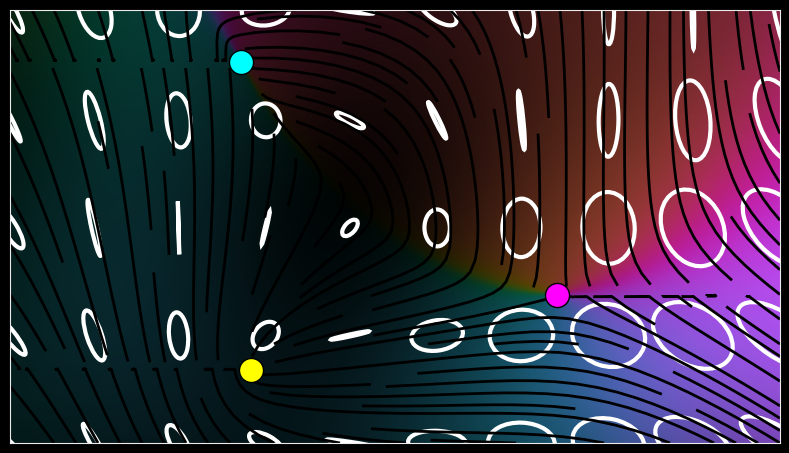

In [8]:
cnf = wl.get_config()

# This position has all 3 types of C points (uncommon)!
cnf.op.size = (16/9*1.5,1.5)
cnf.op.center = (-7.7,2.9)

cnf.op.spacing = 0.01

polarisation_landscape(cnf,15);

---

## 3. Scalar Decomposition

Why do these vector C-points exist?

We decompose the vector field into Right ($E_R$) and Left ($E_L$) circular scalar components.

The Rule of Intersection:
- A Right-Handed C-point (Pure Right Pol) exists exactly where the Left Component is zero ($E_L = 0$).
- A Left-Handed C-point (Pure Left Pol) exists exactly where the Right Component is zero ($E_R = 0$).

This experiment proves that a Vector Singularity is physically caused by a Scalar Phase Vortex in the *orthogonal* component.

In [9]:
def scalar_comps(config, z_val, u=[1,-1j]):
    """
    Visualise phase and circulation (phase gradient) wl right and left circular components.
    Uses analytic field derivatives from compute_on_op.
    """
    engine = wl.setup_engine(config)
    print('Computing field data...')
    fields = engine.compute_on_op(z=z_val, need_b=False)
    finder = wl.SingularityFinder(engine)
    singularities = finder.find_stokes_C_points(z_val, fields.E)
    sinks_r = [point['position'][:2] for point in singularities if point['handedness']>0]
    sinks_l = [point['position'][:2] for point in singularities if point['handedness']<0]

    # Circular components
    data = wl.decompose_in_basis(fields.E[0], fields.E[1], u)
    E_R, E_L = data['E_u'], data['E_v']

    # Their spatial derivatives (using analytic derivatives returned by engine)
    data_dx = wl.decompose_in_basis(fields.dE_dx[0], fields.dE_dx[1], u)
    data_dy = wl.decompose_in_basis(fields.dE_dy[0], fields.dE_dy[1], u)

    E_Rx, E_Lx = data_dx['E_u'], data_dx['E_v']
    E_Ry, E_Ly = data_dy['E_u'], data_dy['E_v']

    # Phase gradients (velocity-like field)
    grad_phi_Rx = np.imag(E_Rx / E_R)
    grad_phi_Ry = np.imag(E_Ry / E_R)
    grad_phi_Lx = np.imag(E_Lx / E_L)
    grad_phi_Ly = np.imag(E_Ly / E_L)

    phi_R = np.angle(E_R)
    phi_L = np.angle(E_L)
    extent = engine.op_extent

    scale = 7 *1/max(config.op.size)
    figsize = (2.1 *config.op.size[0] *scale , config.op.size[1] *scale )    
    
    fig, axs = plt.subplots(1, 2, figsize=figsize)
    cmap = 'twilight_shifted'

    # Right circular
    im0 = axs[0].imshow(phi_R, extent=extent, cmap=cmap, origin='lower')
    axs[0].streamplot(engine.X, engine.Y, grad_phi_Rx, grad_phi_Ry, color='k', density=2.5, linewidth=1.5)
    axs[0].set_title('Right Circular (E_R phase & circulation)')
    axs[0].scatter(*zip(*sinks_l),s=70,color='yellow')
    fig.colorbar(im0, ax=axs[0], shrink=0.8)

    # Left circular
    im1 = axs[1].imshow(phi_L, extent=extent, cmap=cmap, origin='lower')
    axs[1].streamplot(engine.X, engine.Y, grad_phi_Lx, grad_phi_Ly, color='k', density=2.5, linewidth=1.5)
    axs[1].set_title('Left Circular (E_L phase & circulation)')
    axs[1].scatter(*zip(*sinks_r),s=70,color='yellow')
    fig.colorbar(im1, ax=axs[1], shrink=0.8)

    for ax in axs:
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_xlim(engine.x.min(), engine.x.max())
        ax.set_ylim(engine.y.min(), engine.y.max())

    plt.tight_layout()
    plt.show()
    return E_R, E_L

Computing field data...


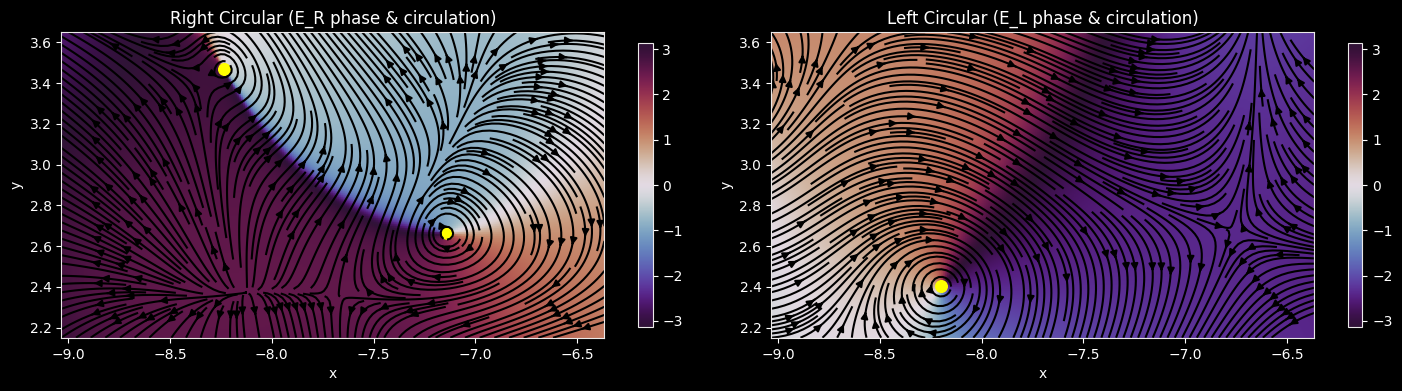

In [10]:
scalar_comps(cnf,15);

---

## 4. C-point statistics

It is meaningful to compute the density of these C-points, as they dictate the polarisation landscape. 

The following helper  is used to do a sigma_k_perp sweep-which takes the beam from paraxial to isotropic limit.

In [11]:
def stokes_C_stats(config,z_val):
    # Experiment to see the stokes C points statistics
    engine = wl.setup_engine(config)
    finder = wl.SingularityFinder(engine)
    fields = engine.compute_on_op(z=z_val,need_b=False,need_derivs=False)
    
    points = finder.find_stokes_C_points(z_val, fields.E)
    
    d_C = len(points) / (config.op.size[0]*config.op.size[1])
    point_types = [pt['type'] for pt in points]
    counts = Counter(point_types)
    counts = {typ: count / len(points) for typ, count in counts.items()}

    return d_C, counts

100%|██████████| 5/5 [00:12<00:00,  2.52s/it]


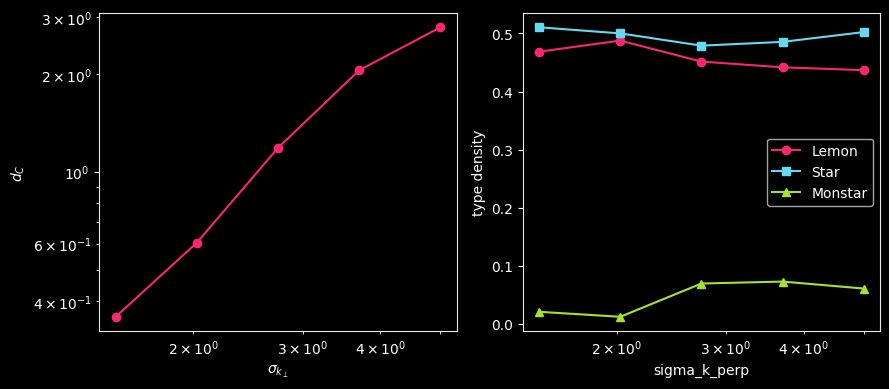

In [12]:
config = wl.get_config()
config.source.theta_max = np.pi
config.source.num_modes = 10_000
config.op.size = (20,20)
config.op.spacing = 0.1

sigmas = np.geomspace(1.5, 5, num=5)
all_d_C = []
all_counts = []
for sigma in tqdm(sigmas):
    config.source.k_space.gaussian(sigma_k_perp= sigma)
    d_C, counts = stokes_C_stats(config,10)
    all_d_C.append(d_C)
    all_counts.append(counts)

lemons   = [c.get('Lemon', 0) for c in all_counts]
stars    = [c.get('Star', 0) for c in all_counts]
monstars = [c.get('Monstar', 0) for c in all_counts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

ax1.loglog(sigmas, all_d_C, marker='o')
ax1.set_xlabel(r'$\sigma_{k_\perp}$')
ax1.set_ylabel(r'$d_C$')

ax2.plot(sigmas, lemons, marker='o', label='Lemon')
ax2.plot(sigmas, stars, marker='s', label='Star')
ax2.plot(sigmas, monstars, marker='^', label='Monstar')
ax2.set_xscale('log')
ax2.set_xlabel('sigma_k_perp')
ax2.set_ylabel('type density')
ax2.legend()

plt.tight_layout()
plt.show()

The plot above confirms a fundamental result in Singular Optics:

1.  Density ($d_C$): As the beam becomes more isotropic (higher sigma_k_perp), defects are packed tighter.
2.  Ratios: Regardless of the density, the relative fraction of Lemons, Stars, and Monstars tends toward specific constants for isotropic random fields (approx 47% Lemons, 50% Stars, 3% Monstars).

In [13]:
print("Total time taken", time.time()-start)

Total time taken 29.723616361618042
